In [1]:
import pandas as pd

# Using the absolute path you specified, so there's no ambiguity about
# which folder pandas is reading from — no dependency on which directory
# your terminal/notebook happens to be running from.
extended_path = r"C:\Users\dahue\Athlete_Career_Intelligence\data\raw\PlayerStatisticsExtended.csv"

# Loading only a small sample first (10 rows) to inspect structure without
# waiting on a 433 MB file load.
extended_sample = pd.read_csv(extended_path, nrows=10)

# Quick sanity checks before we trust this data:
print(f"Number of columns: {len(extended_sample.columns)}")
print(f"Column names:\n{extended_sample.columns.tolist()}")

Number of columns: 110
Column names:
['firstName', 'lastName', 'personId', 'gameId', 'gameDateTimeEst', 'gameType', 'gameLabel', 'gameSubLabel', 'seriesGameNumber', 'win', 'home', 'playerteamId', 'playerteamCity', 'playerteamName', 'opponentteamId', 'opponentteamCity', 'opponentteamName', 'comment', 'startingPosition', 'numMinutes', 'points', 'assists', 'reboundsTotal', 'reboundsOffensive', 'reboundsDefensive', 'fieldGoalsMade', 'fieldGoalsAttempted', 'fieldGoalsPercentage', 'threePointersMade', 'threePointersAttempted', 'threePointersPercentage', 'freeThrowsMade', 'freeThrowsAttempted', 'freeThrowsPercentage', 'steals', 'blocks', 'blocksAgainst', 'turnovers', 'foulsPersonal', 'foulsAgainst', 'plusMinusPoints', 'doubleDouble', 'tripleDouble', 'estimatedOffensiveRating', 'offensiveRating', 'spWorkOffensiveRating', 'estimatedDefensiveRating', 'defensiveRating', 'spWorkDefensiveRating', 'estimatedNetRating', 'netRating', 'spWorkNetRating', 'assistPercentage', 'assistToTurnoverRatio', 'ass

In [2]:
# Printing all 110 column names, one per line, so it's easier to scan
# through them instead of one long wrapped string.
for col in extended_sample.columns:
    print(col)

firstName
lastName
personId
gameId
gameDateTimeEst
gameType
gameLabel
gameSubLabel
seriesGameNumber
win
home
playerteamId
playerteamCity
playerteamName
opponentteamId
opponentteamCity
opponentteamName
comment
startingPosition
numMinutes
points
assists
reboundsTotal
reboundsOffensive
reboundsDefensive
fieldGoalsMade
fieldGoalsAttempted
fieldGoalsPercentage
threePointersMade
threePointersAttempted
threePointersPercentage
freeThrowsMade
freeThrowsAttempted
freeThrowsPercentage
steals
blocks
blocksAgainst
turnovers
foulsPersonal
foulsAgainst
plusMinusPoints
doubleDouble
tripleDouble
estimatedOffensiveRating
offensiveRating
spWorkOffensiveRating
estimatedDefensiveRating
defensiveRating
spWorkDefensiveRating
estimatedNetRating
netRating
spWorkNetRating
assistPercentage
assistToTurnoverRatio
assistRatio
offensiveReboundPercentage
defensiveReboundPercentage
reboundPercentage
teamTurnoverPercentage
estimatedTurnoverPercentage
effectiveFieldGoalPercentage
trueShootingPercentage
usagePercentage
e

In [3]:
columns_needed = [
    "personId", "firstName", "lastName", "gameDateTimeEst", "gameType",  # changed gameDate -> gameDateTimeEst
    "numMinutes", "points", "reboundsTotal", "reboundsOffensive", "reboundsDefensive",
    "assists", "steals", "blocks", "turnovers",
    "fieldGoalsMade", "fieldGoalsAttempted",
    "threePointersMade", "threePointersAttempted",
    "freeThrowsMade", "freeThrowsAttempted",
    "usagePercentage", "assistPercentage",
    "percentPoints3Point", "percentPointsInPaint", "percentPointsFastBreak",
    "percentAssisted3PointMade", "percentAssisted2PointMade",
]
extended_path = r"C:\Users\dahue\Athlete_Career_Intelligence\data\raw\PlayerStatisticsExtended.csv"
df = pd.read_csv(extended_path, usecols=columns_needed)

# --- Step 2: keep regular season only ---
# We haven't seen the exact values of gameType yet — check them first.
print(df["gameType"].unique())

['Playoffs' 'Play-in Tournament' 'Regular Season' 'All-Star Game'
 'Emirates NBA Cup' 'Preseason' 'NBA Emirates Cup' 'Pre Season']


C:\Users\dahue\AppData\Local\Temp\ipykernel_13228\914794297.py:13: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(extended_path, usecols=columns_needed)


In [4]:
# This forces pandas to scan the whole file in one pass instead of chunks,
# which resolves the ambiguity warning and gives us reliable dtypes.
df = pd.read_csv(extended_path, usecols=columns_needed, low_memory=False)

# Check the resulting data type of each column
print(df.dtypes)

firstName                     object
lastName                      object
personId                       int64
gameDateTimeEst               object
gameType                      object
numMinutes                    object
points                       float64
assists                      float64
reboundsTotal                float64
reboundsOffensive            float64
reboundsDefensive            float64
fieldGoalsMade               float64
fieldGoalsAttempted          float64
threePointersMade            float64
threePointersAttempted       float64
freeThrowsMade               float64
freeThrowsAttempted          float64
steals                       float64
blocks                       float64
turnovers                    float64
assistPercentage             float64
usagePercentage              float64
percentPoints3Point          float64
percentPointsFastBreak       float64
percentPointsInPaint         float64
percentAssisted2PointMade    float64
percentAssisted3PointMade    float64
d

In [5]:
# Sampling 20 raw values from numMinutes to see what formats are actually in there
print(df["numMinutes"].sample(20, random_state=42))

# Also checking specifically for null/missing values, since those often
# explain why a numeric-looking column ends up typed as "object"
print(f"\nNull values: {df['numMinutes'].isnull().sum()} out of {len(df)}")

181194      NaN
10915     18.51
581207      3.0
14047     31.21
208245     31.0
362778      7.0
455482     30.0
533469     36.0
643442     27.0
145516     13.0
211689     30.0
3426      34.17
471919     35.0
219537     27.0
237911     27.0
537375     21.0
14678     15.09
732895      9.0
441432      6.0
457852     29.0
Name: numMinutes, dtype: object

Null values: 1257 out of 838803


In [6]:
# errors="coerce" tells pandas: try to convert every value to a number,
# and for anything that fails, replace it with NaN instead of crashing.
numeric_attempt = pd.to_numeric(df["numMinutes"], errors="coerce")

# Now we compare: any row that is NaN in numeric_attempt but was NOT NaN
# in the original column must be a value that failed conversion — i.e.,
# something that isn't a clean number.
problematic_mask = numeric_attempt.isnull() & df["numMinutes"].notnull()

print(f"Problematic values found: {problematic_mask.sum()}")
print(df.loc[problematic_mask, "numMinutes"].unique())

Problematic values found: 2096
['6:08' '19:19' '16:49' ... '36:16' '3:42' '15:07']


In [7]:
def convert_minutes(value):
    """
    Converts a numMinutes value into a clean float representing minutes played.

    Handles two formats found in this column:
      - Decimal minutes as text or number, e.g. 18.51 or "18.51"
      - "MM:SS" format as text, e.g. "6:08" (6 minutes, 8 seconds)

    Returns float("nan") for missing values, so they stay as proper
    NaN and don't silently become 0 (which would be misleading —
    a missing value is not the same as "played zero minutes").
    """
    # --- Case 1: missing value ---
    # pd.isna() correctly detects NaN even though, at this point, `value`
    # could technically be a float, a string, or actually missing —
    # this check has to come first, before we try any string operations,
    # because calling .split() on a NaN would raise an error.
    if pd.isna(value):
        return float("nan")

    # --- Case 2: "MM:SS" format ---
    # We only reach this branch if value is NOT missing. Checking for ":"
    # tells us whether we're dealing with the "MM:SS" text format.
    if ":" in str(value):
        minutes_part, seconds_part = str(value).split(":")
        # Converting each piece to a number, then combining them into
        # a single decimal value: e.g. "6:08" -> 6 + 8/60 = 6.1333...
        return int(minutes_part) + int(seconds_part) / 60

    # --- Case 3: already a plain number (as float or as numeric string) ---
    # float() handles both cases directly: float(18.51) -> 18.51,
    # and float("18.51") -> 18.51 as well.
    return float(value)


# Applying the function to every row in the column.
# .apply() runs convert_minutes() once per value in the Series and
# collects the results into a new Series of the same length.
df["numMinutes_clean"] = df["numMinutes"].apply(convert_minutes)

# --- Verification: confirm no string values remain ---
# isinstance(x, str) checks, for each value, whether it's still a
# leftover string (meaning our conversion missed something).
# .sum() on a boolean Series counts how many True values there are —
# we expect this to print 0 if the conversion worked correctly.
remaining_strings = df["numMinutes_clean"].apply(lambda x: isinstance(x, str)).sum()
print(f"Remaining string values (should be 0): {remaining_strings}")

# --- Sanity check: compare a few converted "MM:SS" values against the originals ---
# Filtering the original column for rows that had the ":" format, and
# showing both the original and converted value side by side, so you can
# visually confirm the math is right (e.g. "6:08" should now read ~6.13).
mmss_mask = df["numMinutes"].astype(str).str.contains(":", na=False)
print(df.loc[mmss_mask, ["numMinutes", "numMinutes_clean"]].head(10))

Remaining string values (should be 0): 0
       numMinutes  numMinutes_clean
836707       6:08          6.133333
836708      19:19         19.316667
836709      16:49         16.816667
836710       6:05          6.083333
836711      16:17         16.283333
836712      25:04         25.066667
836713       8:27          8.450000
836714       8:02          8.033333
836715      16:22         16.366667
836716      19:35         19.583333


In [8]:
import numpy as np
import pandas as pd

# --- Step 1: keep only Regular Season games ---
df_regular = df[df["gameType"] == "Regular Season"].copy()

# --- Step 2: parse the datetime column into a real date ---
df_regular["gameDateTimeEst"] = pd.to_datetime(df_regular["gameDateTimeEst"])

# --- Step 3: derive the NBA season label from the date ---
def get_season(date):
    if date.month >= 10:
        start_year = date.year
    else:
        start_year = date.year - 1
    end_year_short = str(start_year + 1)[-2:]
    return f"{start_year}-{end_year_short}"

df_regular["season"] = df_regular["gameDateTimeEst"].apply(get_season)

# --- Step 4: aggregate game-by-game rows into one row per player per season ---
grouped = df_regular.groupby(["personId", "season"])

season_stats = grouped.agg(
    firstName=("firstName", "first"),
    lastName=("lastName", "first"),
    games_played=("personId", "count"),
    avg_minutes=("numMinutes_clean", "mean"),
    points_pg=("points", "mean"),
    rebounds_pg=("reboundsTotal", "mean"),
    assists_pg=("assists", "mean"),
    steals_pg=("steals", "mean"),
    blocks_pg=("blocks", "mean"),
    turnovers_pg=("turnovers", "mean"),
    fgm_total=("fieldGoalsMade", "sum"),
    fga_total=("fieldGoalsAttempted", "sum"),
    tpm_total=("threePointersMade", "sum"),
    tpa_total=("threePointersAttempted", "sum"),
    ftm_total=("freeThrowsMade", "sum"),
    fta_total=("freeThrowsAttempted", "sum"),
).reset_index()

# --- Step 5: recomputed shooting percentages ---
season_stats["fg_pct"] = np.where(season_stats["fga_total"] > 0, season_stats["fgm_total"] / season_stats["fga_total"], np.nan)
season_stats["tp_pct"] = np.where(season_stats["tpa_total"] > 0, season_stats["tpm_total"] / season_stats["tpa_total"], np.nan)
season_stats["ft_pct"] = np.where(season_stats["fta_total"] > 0, season_stats["ftm_total"] / season_stats["fta_total"], np.nan)

# --- Step 6: weighted averages for advanced percentage columns ---
def weighted_avg(group, value_col, weight_col="numMinutes_clean"):
    valid = group.dropna(subset=[value_col])
    if valid[weight_col].sum() == 0:
        return np.nan
    return (valid[value_col] * valid[weight_col]).sum() / valid[weight_col].sum()

weighted_cols = ["usagePercentage", "assistPercentage",
                  "percentPoints3Point", "percentPointsInPaint", "percentPointsFastBreak",
                  "percentAssisted3PointMade", "percentAssisted2PointMade"]

weighted_results = []
for col in weighted_cols:
    result = df_regular.groupby(["personId", "season"]).apply(
        lambda g: weighted_avg(g, col),
        include_groups=False
    )
    result.name = col + "_wavg"
    weighted_results.append(result)

weighted_df = pd.concat(weighted_results, axis=1).reset_index()
season_stats = season_stats.merge(weighted_df, on=["personId", "season"], how="left")

print(f"season_stats shape: {season_stats.shape}")
print(season_stats.columns.tolist())

season_stats shape: (14569, 28)
['personId', 'season', 'firstName', 'lastName', 'games_played', 'avg_minutes', 'points_pg', 'rebounds_pg', 'assists_pg', 'steals_pg', 'blocks_pg', 'turnovers_pg', 'fgm_total', 'fga_total', 'tpm_total', 'tpa_total', 'ftm_total', 'fta_total', 'fg_pct', 'tp_pct', 'ft_pct', 'usagePercentage_wavg', 'assistPercentage_wavg', 'percentPoints3Point_wavg', 'percentPointsInPaint_wavg', 'percentPointsFastBreak_wavg', 'percentAssisted3PointMade_wavg', 'percentAssisted2PointMade_wavg']


In [9]:
# --- Recomputing shooting percentages from season totals ---
# This is the mathematically correct approach we discussed: dividing the
# SUM of makes by the SUM of attempts for the whole season, rather than
# averaging each game's percentage.
#
# np.where() is used instead of a plain division to handle players with
# zero attempts all season (e.g. a center who never once tried a 3-pointer) —
# dividing by zero would otherwise produce an error or a confusing "inf" value.
# np.where(condition, value_if_true, value_if_false) checks the condition
# for every row at once.
season_stats["fg_pct"] = np.where(
    season_stats["fga_total"] > 0,
    season_stats["fgm_total"] / season_stats["fga_total"],
    np.nan  # if a player never attempted a shot, the percentage is undefined, not 0
)

season_stats["tp_pct"] = np.where(
    season_stats["tpa_total"] > 0,
    season_stats["tpm_total"] / season_stats["tpa_total"],
    np.nan
)

season_stats["ft_pct"] = np.where(
    season_stats["fta_total"] > 0,
    season_stats["ftm_total"] / season_stats["fta_total"],
    np.nan
)

# --- Weighted averages for the advanced percentage columns ---
# These (usagePercentage, assistPercentage, and the "percentPoints*" family)
# don't have a simple "made/attempted" pair behind them, so we can't
# recompute them from raw totals like we just did above. Instead, we weight
# each game's value by the minutes played that game, so a 35-minute game
# counts more than a 4-minute one.
#
# We can't use .agg() with a simple "mean" for this — we need a custom
# calculation per group, so we build a small helper function and apply it
# with .apply() on the grouped data instead.
def weighted_avg(group, value_col, weight_col="numMinutes_clean"):
    # Dropping rows where the value itself is missing, so they don't
    # distort the weighted average.
    valid = group.dropna(subset=[value_col])
    if valid[weight_col].sum() == 0:
        return np.nan
    return (valid[value_col] * valid[weight_col]).sum() / valid[weight_col].sum()

# Re-grouping the ORIGINAL game-level data (df_regular), not season_stats,
# because we need access to the individual game rows to compute the
# weighted average — season_stats already collapsed that detail away.
weighted_cols = ["usagePercentage", "assistPercentage",
                  "percentPoints3Point", "percentPointsInPaint", "percentPointsFastBreak",
                  "percentAssisted3PointMade", "percentAssisted2PointMade"]

weighted_results = []
for col in weighted_cols:
    result = df_regular.groupby(["personId", "season"]).apply(
    lambda g: weighted_avg(g, col),
    include_groups=False
)
    result.name = col + "_wavg"
    weighted_results.append(result)

# Combining all the weighted-average Series into a single DataFrame, then
# merging it onto season_stats using personId + season as the shared key.
weighted_df = pd.concat(weighted_results, axis=1).reset_index()
season_stats = season_stats.merge(weighted_df, on=["personId", "season"], how="left")

print(season_stats.head(10))
print(f"\nFinal shape: {season_stats.shape}")

   personId   season firstName lastName  games_played  avg_minutes  points_pg  \
0         2  1996-97     Byron    Scott            79    17.721519   6.658228   
1         3  1996-97     Grant     Long            65    17.553846   5.015385   
2         3  1997-98     Grant     Long            40    18.125000   3.525000   
3         3  1998-99     Grant     Long            50    27.120000   9.780000   
4         3  1999-00     Grant     Long            42    21.476190   4.833333   
5         3  2000-01     Grant     Long            66    22.393939   6.000000   
6         3  2001-02     Grant     Long            66    27.772727   6.318182   
7         3  2002-03     Grant     Long            41    11.414634   1.756098   
8         7  1996-97       Dan  Schayes            45    11.511111   2.955556   
9         7  1997-98       Dan  Schayes            74    16.729730   5.486486   

   rebounds_pg  assists_pg  steals_pg  ...  percentPointsFastBreak_wavg_x  \
0     1.493671    1.253165   0.

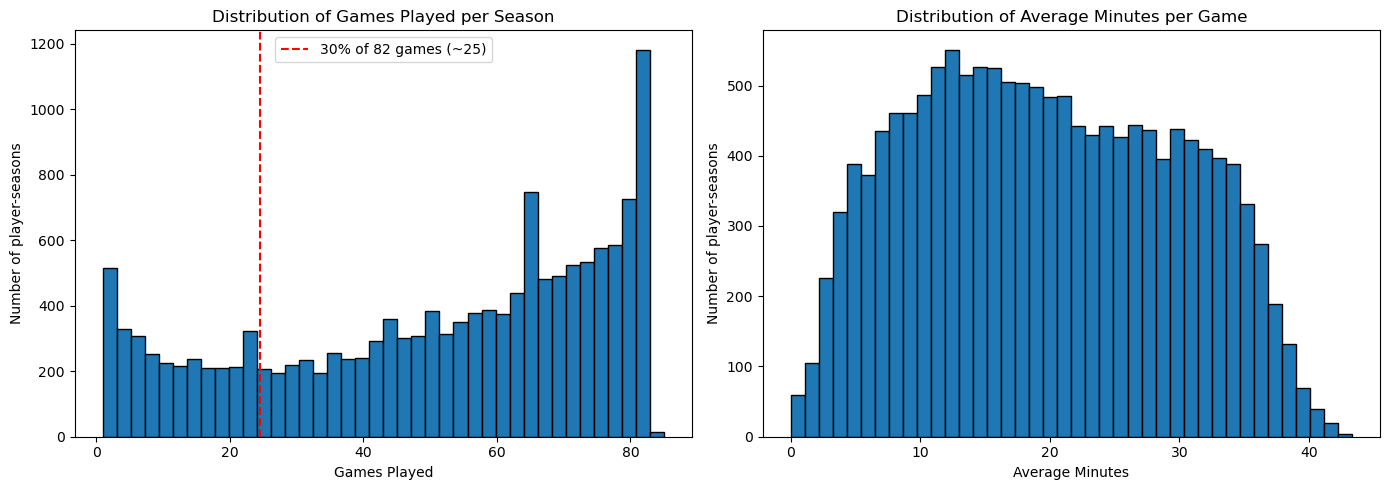

games_played percentiles:
count    14569.000000
mean        50.440593
std         25.086641
min          1.000000
10%         10.000000
25%         30.000000
50%         56.000000
75%         72.000000
90%         80.000000
max         85.000000
Name: games_played, dtype: float64

avg_minutes percentiles:
count    14569.000000
mean        19.638388
std          9.927205
min          0.000000
10%          6.444444
25%         11.500000
50%         19.071429
75%         27.818182
90%         33.527937
max         43.316667
Name: avg_minutes, dtype: float64


In [10]:
import matplotlib.pyplot as plt

# Creating two histograms side by side, one for games played and one for
# average minutes per game — this lets us visually spot natural cutoff
# points in the distribution instead of picking thresholds arbitrarily.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Histogram 1: games played ---
axes[0].hist(season_stats["games_played"], bins=40, edgecolor="black")
axes[0].set_title("Distribution of Games Played per Season")
axes[0].set_xlabel("Games Played")
axes[0].set_ylabel("Number of player-seasons")
# Adding a vertical reference line at 30% of an 82-game season (~25 games),
# just as a visual anchor — not a final decision yet.
axes[0].axvline(x=82 * 0.3, color="red", linestyle="--", label="30% of 82 games (~25)")
axes[0].legend()

# --- Histogram 2: average minutes per game ---
axes[1].hist(season_stats["avg_minutes"], bins=40, edgecolor="black")
axes[1].set_title("Distribution of Average Minutes per Game")
axes[1].set_xlabel("Average Minutes")
axes[1].set_ylabel("Number of player-seasons")

plt.tight_layout()  # prevents titles/labels from overlapping between the two plots
plt.show()

# Also printing some descriptive statistics as numbers, since histograms
# can be hard to read precisely — percentiles help pick a concrete cutoff.
print("games_played percentiles:")
print(season_stats["games_played"].describe(percentiles=[.1, .25, .5, .75, .9]))

print("\navg_minutes percentiles:")
print(season_stats["avg_minutes"].describe(percentiles=[.1, .25, .5, .75, .9]))

In [11]:
# Applying the games_played filter first (the one we're confident about),
# then looking specifically at the avg_minutes distribution WITHIN that
# already-filtered group — this shows us the real shape of the "specialist"
# zone instead of guessing.
consistent_players = season_stats[season_stats["games_played"] >= 25].copy()

print(f"Player-seasons with 25+ games: {len(consistent_players)}")
print("\navg_minutes distribution among players with 25+ games:")
print(consistent_players["avg_minutes"].describe(percentiles=[.05, .1, .15, .2, .25]))

# How many "deep specialists" (sustained role, but low minutes) are there
# at a few different candidate thresholds?
for threshold in [5, 6, 8, 10, 12, 15]:
    count = (consistent_players["avg_minutes"] >= threshold).sum()
    lost = len(consistent_players) - count
    print(f"Threshold {threshold} min: keeps {count} player-seasons, loses {lost} specialists below it")

Player-seasons with 25+ games: 11530

avg_minutes distribution among players with 25+ games:
count    11530.000000
mean        22.214925
std          8.885732
min          2.375000
5%           8.222222
10%         10.346021
15%         11.982759
20%         13.563030
25%         15.000000
50%         22.003000
max         43.316667
Name: avg_minutes, dtype: float64
Threshold 5 min: keeps 11448 player-seasons, loses 82 specialists below it
Threshold 6 min: keeps 11344 player-seasons, loses 186 specialists below it
Threshold 8 min: keeps 11017 player-seasons, loses 513 specialists below it
Threshold 10 min: keeps 10474 player-seasons, loses 1056 specialists below it
Threshold 12 min: keeps 9799 player-seasons, loses 1731 specialists below it
Threshold 15 min: keeps 8656 player-seasons, loses 2874 specialists below it


In [17]:
import numpy as np
import pandas as pd

df_regular = df[df["gameType"] == "Regular Season"].copy()
df_regular["gameDateTimeEst"] = pd.to_datetime(df_regular["gameDateTimeEst"])

def get_season(date):
    if date.month >= 10:
        start_year = date.year
    else:
        start_year = date.year - 1
    end_year_short = str(start_year + 1)[-2:]
    return f"{start_year}-{end_year_short}"

df_regular["season"] = df_regular["gameDateTimeEst"].apply(get_season)

grouped = df_regular.groupby(["personId", "season"])

season_stats = grouped.agg(
    firstName=("firstName", "first"),
    lastName=("lastName", "first"),
    games_played=("personId", "count"),
    avg_minutes=("numMinutes_clean", "mean"),
    points_pg=("points", "mean"),
    rebounds_pg=("reboundsTotal", "mean"),
    assists_pg=("assists", "mean"),
    steals_pg=("steals", "mean"),
    blocks_pg=("blocks", "mean"),
    turnovers_pg=("turnovers", "mean"),
    fgm_total=("fieldGoalsMade", "sum"),
    fga_total=("fieldGoalsAttempted", "sum"),
    tpm_total=("threePointersMade", "sum"),
    tpa_total=("threePointersAttempted", "sum"),
    ftm_total=("freeThrowsMade", "sum"),
    fta_total=("freeThrowsAttempted", "sum"),
).reset_index()

season_stats["fg_pct"] = np.where(season_stats["fga_total"] > 0, season_stats["fgm_total"] / season_stats["fga_total"], np.nan)
season_stats["tp_pct"] = np.where(season_stats["tpa_total"] > 0, season_stats["tpm_total"] / season_stats["tpa_total"], np.nan)
season_stats["ft_pct"] = np.where(season_stats["fta_total"] > 0, season_stats["ftm_total"] / season_stats["fta_total"], np.nan)

def weighted_avg(group, value_col, weight_col="numMinutes_clean"):
    valid = group.dropna(subset=[value_col])
    if valid[weight_col].sum() == 0:
        return np.nan
    return (valid[value_col] * valid[weight_col]).sum() / valid[weight_col].sum()

weighted_cols = ["usagePercentage", "assistPercentage",
                  "percentPoints3Point", "percentPointsInPaint", "percentPointsFastBreak",
                  "percentAssisted3PointMade", "percentAssisted2PointMade"]

weighted_results = []
for col in weighted_cols:
    result = df_regular.groupby(["personId", "season"]).apply(
        lambda g: weighted_avg(g, col),
        include_groups=False
    )
    result.name = col + "_wavg"
    weighted_results.append(result)

weighted_df = pd.concat(weighted_results, axis=1).reset_index()

# --- SAFETY NET: this is the new part ---
# Because season_stats was JUST built from scratch a few lines above (not
# reused from a previous run), it's technically impossible for it to already
# have _wavg columns at this point in THIS execution. But this guard makes
# that fact explicit and enforced in code, rather than relying on you (or
# future-you) remembering to Restart the kernel correctly. If, for any
# reason, season_stats already contains any of these columns, we drop them
# first — so the merge below can never produce _x/_y duplicates, no matter
# how many times or in what state this cell gets run.
cols_to_drop = [c for c in weighted_df.columns if c in season_stats.columns and c not in ["personId", "season"]]
if cols_to_drop:
    season_stats = season_stats.drop(columns=cols_to_drop)

season_stats = season_stats.merge(weighted_df, on=["personId", "season"], how="left")

print(f"season_stats shape: {season_stats.shape}")
assert not any(col.endswith(("_x", "_y")) for col in season_stats.columns), \
    "Duplicate suffixes detected — something is still wrong with re-execution"
print("No duplicate suffixes found — safe to proceed.")

season_stats shape: (14569, 28)
No duplicate suffixes found — safe to proceed.


In [19]:
# --- Step 1: apply the two documented thresholds ---
games_played_min = 25
avg_minutes_min = 8

season_stats_filtered = season_stats[
    (season_stats["games_played"] >= games_played_min) &
    (season_stats["avg_minutes"] >= avg_minutes_min)
].copy()

print(f"Before filtering: {len(season_stats)} player-seasons")
print(f"After filtering: {len(season_stats_filtered)} player-seasons")
print(f"Removed: {len(season_stats) - len(season_stats_filtered)} "
      f"({(1 - len(season_stats_filtered)/len(season_stats)):.1%})")

# --- Step 2: define the final feature set, matching actual column names ---
feature_cols = [
    "avg_minutes", "points_pg", "rebounds_pg", "assists_pg",
    "steals_pg", "blocks_pg", "turnovers_pg",
    "fg_pct", "tp_pct", "ft_pct",
    "usagePercentage_wavg", "assistPercentage_wavg",
    "percentPoints3Point_wavg", "percentPointsInPaint_wavg", "percentPointsFastBreak_wavg",
    "percentAssisted3PointMade_wavg", "percentAssisted2PointMade_wavg",
]

# --- Step 3: check for missing values before deciding how to handle them ---
print("\nMissing values per feature:")
print(season_stats_filtered[feature_cols].isnull().sum())

Before filtering: 14569 player-seasons
After filtering: 11017 player-seasons
Removed: 3552 (24.4%)

Missing values per feature:
avg_minutes                         0
points_pg                           0
rebounds_pg                         0
assists_pg                          0
steals_pg                           0
blocks_pg                           0
turnovers_pg                        0
fg_pct                              0
tp_pct                            850
ft_pct                              2
usagePercentage_wavg                0
assistPercentage_wavg               0
percentPoints3Point_wavg            0
percentPointsInPaint_wavg           0
percentPointsFastBreak_wavg         0
percentAssisted3PointMade_wavg      0
percentAssisted2PointMade_wavg      0
dtype: int64


In [20]:
# Inspecting the two ft_pct null cases specifically, before deciding
# how to handle them — with only 2 rows, manual inspection beats a
# blanket imputation rule.
print(season_stats_filtered[season_stats_filtered["ft_pct"].isnull()][
    ["personId", "season", "firstName", "lastName", "games_played",
     "avg_minutes", "points_pg", "fta_total"]
])

      personId   season firstName  lastName  games_played  avg_minutes  \
3193      1715  2010-11     Jason  Williams            27    10.518519   
5649      2575  2011-12      Luke    Walton            30    11.600000   

      points_pg  fta_total  
3193   2.000000        0.0  
5649   1.833333        0.0  


In [21]:
# Filling both percentage columns with 0 where the player had zero
# attempts all season — this correctly encodes "doesn't take this kind
# of shot" as part of their playing style, rather than leaving it as
# a missing value (which would be interpreted as "unknown" by most
# downstream algorithms, including the clustering we're about to run).
season_stats_filtered["tp_pct"] = season_stats_filtered["tp_pct"].fillna(0)
season_stats_filtered["ft_pct"] = season_stats_filtered["ft_pct"].fillna(0)

# Final check: confirm zero nulls remain across all feature columns
print(season_stats_filtered[feature_cols].isnull().sum().sum(), "total missing values remaining")

0 total missing values remaining


In [22]:
from sklearn.preprocessing import StandardScaler

# --- Standardizing the features ---
# StandardScaler transforms each column so it has mean 0 and standard
# deviation 1. This matters because our features live on very different
# scales right now — points_pg ranges roughly 0-30, while fg_pct ranges
# 0-1. Without scaling, K-Means (which works by measuring distances
# between points) would treat a 1-point difference in points_pg as
# equally important as a 1.0 difference in fg_pct — but a 1.0 difference
# in fg_pct is actually the entire possible range of that variable, so
# it would completely dominate the distance calculation.
scaler = StandardScaler()

# fit_transform() does two things in one call: "fit" calculates the mean
# and standard deviation of each column from this data, and "transform"
# applies the (value - mean) / std_dev formula to every value using
# those numbers. The result is a NumPy array, not a DataFrame, so we
# wrap it back into a DataFrame with the original column names and index
# to keep it easy to work with.
scaled_array = scaler.fit_transform(season_stats_filtered[feature_cols])
scaled_df = pd.DataFrame(scaled_array, columns=feature_cols, index=season_stats_filtered.index)

# Sanity check: confirm the scaling worked as expected — every column
# should now have a mean very close to 0 and a standard deviation very
# close to 1.
print("Mean after scaling (should be ~0):")
print(scaled_df.mean().round(3))
print("\nStd dev after scaling (should be ~1):")
print(scaled_df.std().round(3))

Mean after scaling (should be ~0):
avg_minutes                      -0.0
points_pg                        -0.0
rebounds_pg                      -0.0
assists_pg                        0.0
steals_pg                        -0.0
blocks_pg                         0.0
turnovers_pg                     -0.0
fg_pct                            0.0
tp_pct                            0.0
ft_pct                           -0.0
usagePercentage_wavg              0.0
assistPercentage_wavg             0.0
percentPoints3Point_wavg         -0.0
percentPointsInPaint_wavg         0.0
percentPointsFastBreak_wavg      -0.0
percentAssisted3PointMade_wavg   -0.0
percentAssisted2PointMade_wavg   -0.0
dtype: float64

Std dev after scaling (should be ~1):
avg_minutes                       1.0
points_pg                         1.0
rebounds_pg                       1.0
assists_pg                        1.0
steals_pg                         1.0
blocks_pg                         1.0
turnovers_pg                      1.0

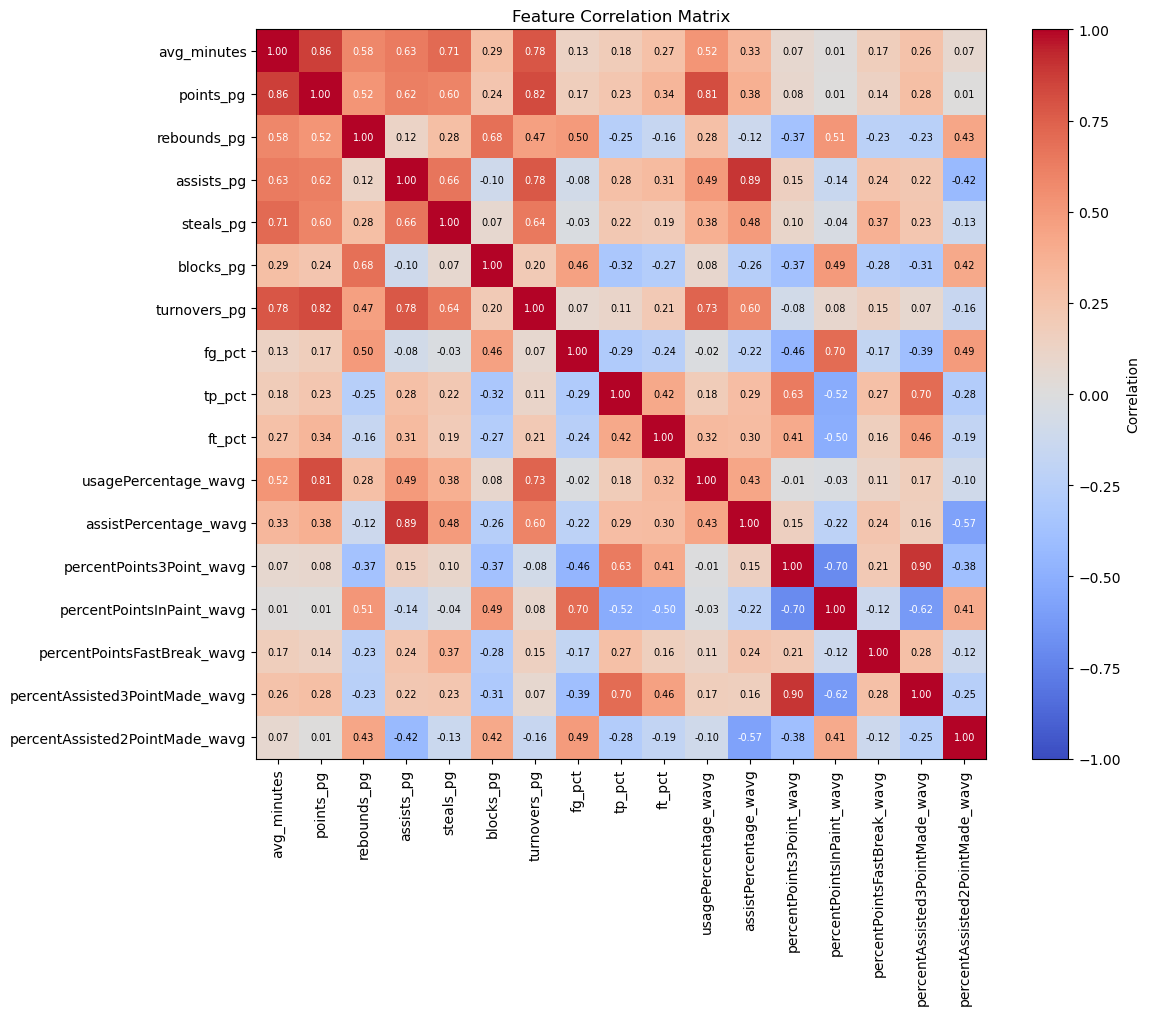

Strongest feature correlations (|r| > 0.5):
percentAssisted3PointMade_wavg  percentPoints3Point_wavg          0.897612
percentPoints3Point_wavg        percentAssisted3PointMade_wavg    0.897612
assistPercentage_wavg           assists_pg                        0.891836
assists_pg                      assistPercentage_wavg             0.891836
points_pg                       avg_minutes                       0.862604
avg_minutes                     points_pg                         0.862604
points_pg                       turnovers_pg                      0.823017
turnovers_pg                    points_pg                         0.823017
usagePercentage_wavg            points_pg                         0.813119
points_pg                       usagePercentage_wavg              0.813119
avg_minutes                     turnovers_pg                      0.783924
turnovers_pg                    avg_minutes                       0.783924
                                assists_pg              

In [23]:
import matplotlib.pyplot as plt

# --- Correlation matrix ---
# .corr() computes the pairwise Pearson correlation between every pair
# of columns, producing a 17x17 table where each cell tells you how
# strongly two features move together (-1 = perfectly opposite,
# 0 = unrelated, 1 = perfectly together). We use the scaled version,
# though correlation is actually scale-invariant, so this would give
# the same result as using the unscaled features — we're just reusing
# what we already have.
corr_matrix = scaled_df.corr()

# --- Visualizing it as a heatmap ---
# A plain printed table of 17x17 numbers is hard to scan visually —
# a heatmap lets you spot strong correlations (dark red or dark blue
# cells) at a glance, which is the whole point of doing this check.
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

# Labeling both axes with the feature names, rotated on the x-axis
# so long column names don't overlap each other.
ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=90)
ax.set_yticklabels(feature_cols)

# Adding the actual correlation number as text inside each cell —
# useful for reading exact values once we spot an interesting pair
# visually, without needing to cross-reference a separate printout.
for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center", fontsize=7,
                 color="white" if abs(corr_matrix.iloc[i, j]) > 0.5 else "black")

fig.colorbar(im, label="Correlation")
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# --- Also printing the strongest pairs numerically ---
# Scanning a 17x17 grid by eye can still miss things, so this extracts
# the highest-correlation pairs directly as a sorted list.
corr_pairs = corr_matrix.where(
    ~np.eye(len(corr_matrix), dtype=bool)  # excludes the diagonal (a column always correlates 1.0 with itself)
).unstack().sort_values(ascending=False, key=abs)

# Each pair appears twice (A-B and B-A) since the matrix is symmetric,
# so we take every other row after dropping duplicates.
corr_pairs = corr_pairs[~corr_pairs.index.duplicated()].dropna()
print("Strongest feature correlations (|r| > 0.5):")
print(corr_pairs[corr_pairs.abs() > 0.5])

Component 1: 33.1% (cumulative: 33.1%)
Component 2: 26.8% (cumulative: 59.9%)
Component 3: 10.1% (cumulative: 69.9%)
Component 4: 6.3% (cumulative: 76.2%)
Component 5: 4.8% (cumulative: 81.0%)
Component 6: 4.1% (cumulative: 85.1%)
Component 7: 3.5% (cumulative: 88.6%)
Component 8: 2.5% (cumulative: 91.0%)
Component 9: 2.3% (cumulative: 93.3%)
Component 10: 1.7% (cumulative: 95.0%)
Component 11: 1.5% (cumulative: 96.5%)
Component 12: 1.2% (cumulative: 97.8%)
Component 13: 0.9% (cumulative: 98.7%)
Component 14: 0.6% (cumulative: 99.3%)
Component 15: 0.4% (cumulative: 99.6%)
Component 16: 0.2% (cumulative: 99.9%)
Component 17: 0.1% (cumulative: 100.0%)


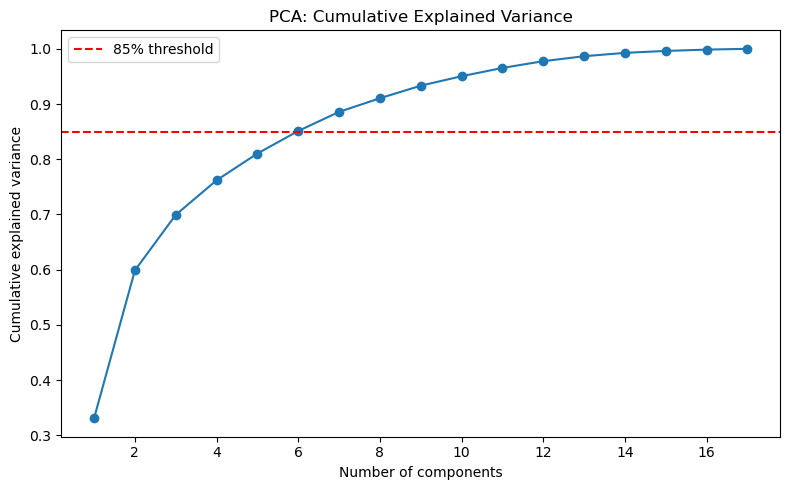

In [24]:
from sklearn.decomposition import PCA

# --- Fitting PCA on the scaled features ---
# We don't specify n_components yet — passing None keeps ALL components
# (same number as input features, 17), which lets us inspect how much
# variance each one explains before deciding how many to actually keep.
pca_full = PCA(n_components=None, random_state=42)
pca_full.fit(scaled_df)

# explained_variance_ratio_ tells us, for each component, what fraction
# of the total variance in the original 17 features it captures.
# cumsum() gives the running total — e.g. "the first 5 components
# together explain 78% of all the variance in the original data".
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

for i, (var, cum) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"Component {i}: {var:.1%} (cumulative: {cum:.1%})")

# --- Visualizing the "elbow" ---
# Plotting cumulative variance helps identify the point of diminishing
# returns — where adding more components stops meaningfully improving
# how much of the original signal you're capturing.
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker="o")
ax.axhline(y=0.85, color="red", linestyle="--", label="85% threshold")
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA: Cumulative Explained Variance")
ax.legend()
plt.tight_layout()
plt.show()

In [25]:
# --- Applying PCA with the chosen number of components ---
n_components = 6

pca = PCA(n_components=n_components, random_state=42)
pca_result = pca.fit_transform(scaled_df)

# Wrapping the result in a DataFrame with clear column names (PC1, PC2...)
# and the same index as season_stats_filtered, so we can still trace each
# row back to the player-season it came from.
pca_df = pd.DataFrame(
    pca_result,
    columns=[f"PC{i+1}" for i in range(n_components)],
    index=season_stats_filtered.index
)

print(f"Variance retained with {n_components} components: {cumulative_var[n_components-1]:.1%}")
print(pca_df.head())

Variance retained with 6 components: 85.1%
        PC1       PC2       PC3       PC4       PC5       PC6
0 -0.034170 -2.636965 -1.100691  0.607381  0.561434  0.076092
1 -1.702940 -0.994550 -0.298773 -0.168855  0.268616  0.213973
2 -2.997203 -0.187736  0.488778  1.221659  0.640214 -1.511894
3 -0.501596  0.881172  0.170828 -0.574943  0.337607 -1.414749
4 -2.042045  0.714486  0.896245  0.350469  0.109329 -1.118024


k=2: silhouette=0.2729, inertia=115916.8
k=3: silhouette=0.2780, inertia=86094.1
k=4: silhouette=0.2554, inertia=75807.9
k=5: silhouette=0.2175, inertia=67614.6
k=6: silhouette=0.2154, inertia=62552.4
k=7: silhouette=0.1970, inertia=58673.9
k=8: silhouette=0.1956, inertia=55488.0
k=9: silhouette=0.1802, inertia=52787.5
k=10: silhouette=0.1747, inertia=50840.9
k=11: silhouette=0.1730, inertia=49032.2
k=12: silhouette=0.1690, inertia=47353.8
k=13: silhouette=0.1679, inertia=45869.9
k=14: silhouette=0.1621, inertia=44535.8
k=15: silhouette=0.1622, inertia=43362.6
k=16: silhouette=0.1606, inertia=42323.1
k=17: silhouette=0.1593, inertia=41311.8
k=18: silhouette=0.1566, inertia=40519.3
k=19: silhouette=0.1601, inertia=39643.4
k=20: silhouette=0.1587, inertia=38951.5


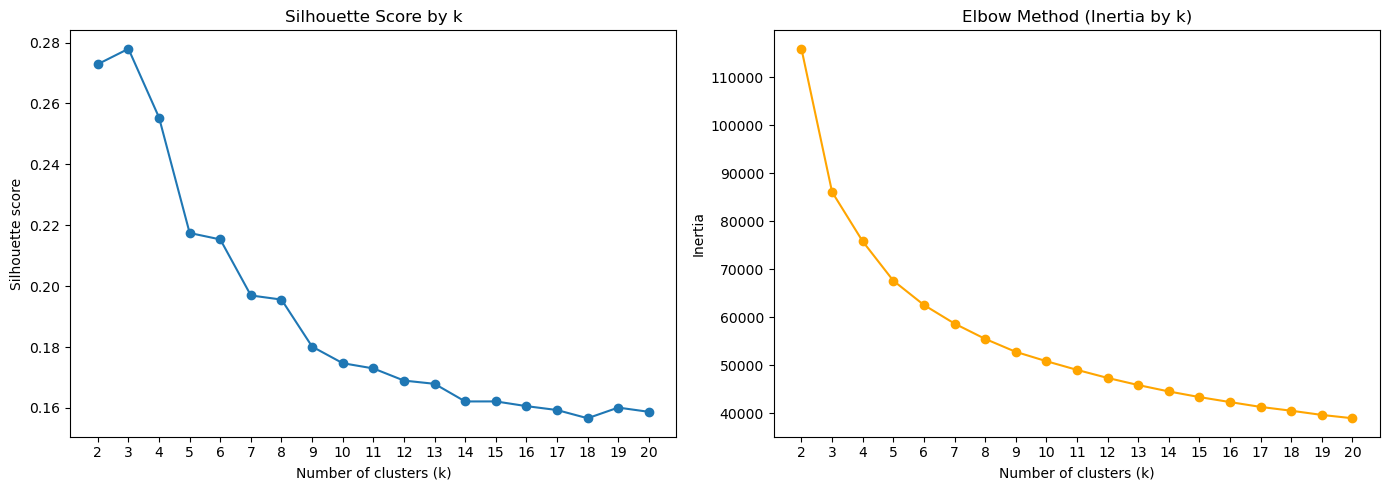

In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- Testing a range of k values ---
# Instead of guessing a single number of clusters, we try several and
# score each one, so the final choice is backed by evidence rather than
# intuition — same principle we've applied to every threshold so far.
k_range = range(2, 21)
silhouette_scores = []
inertia_values = []  # also tracking inertia for a secondary "elbow" check

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(pca_df)

    # Silhouette score measures how well-separated the clusters are:
    # for each point, it compares its average distance to points in its
    # own cluster vs. the nearest other cluster. Ranges from -1 (bad,
    # points would fit better in a different cluster) to +1 (great,
    # clusters are well separated). We average it across all points.
    score = silhouette_score(pca_df, cluster_labels)
    silhouette_scores.append(score)

    # Inertia is the sum of squared distances from each point to its
    # cluster's center — always decreases as k increases, so it's used
    # to find an "elbow" (the point where adding more clusters stops
    # helping much), not an absolute best value.
    inertia_values.append(kmeans.inertia_)

    print(f"k={k}: silhouette={score:.4f}, inertia={kmeans.inertia_:.1f}")

# --- Visualizing both metrics side by side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), silhouette_scores, marker="o")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Silhouette score")
axes[0].set_title("Silhouette Score by k")
axes[0].set_xticks(list(k_range))

axes[1].plot(list(k_range), inertia_values, marker="o", color="orange")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Inertia")
axes[1].set_title("Elbow Method (Inertia by k)")
axes[1].set_xticks(list(k_range))

plt.tight_layout()

In [28]:
# --- Check 1: does reducing to fewer PCA dimensions produce cleaner separation? ---
# If separation improves a lot with just 2 components, that would suggest
# the extra components (3-6) are adding noise rather than real structure.
# If it stays similarly modest, it supports the "genuine continuum" explanation.
pca_2d = PCA(n_components=2, random_state=42)
pca_2d_result = pca_2d.fit_transform(scaled_df)

for k in [3, 8, 12]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_2d = km.fit_predict(pca_2d_result)
    score_2d = silhouette_score(pca_2d_result, labels_2d)
    print(f"k={k}, using only 2 PCA components: silhouette={score_2d:.4f}")

# --- Check 2: at our candidate k=12, how many points are poorly assigned? ---
# Negative silhouette values mean a point is actually closer to a
# DIFFERENT cluster's center than its own — a sign of real overlap
# between archetypes, not a coding problem.
from sklearn.metrics import silhouette_samples

kmeans_12 = KMeans(n_clusters=12, random_state=42, n_init=10)
labels_12 = kmeans_12.fit_predict(pca_df)
sample_scores = silhouette_samples(pca_df, labels_12)

print(f"\nAt k=12:")
print(f"Points with negative silhouette (poorly assigned): {(sample_scores < 0).sum()} "
      f"({(sample_scores < 0).mean():.1%} of {len(sample_scores)})")

# --- Check 3: are cluster sizes reasonably balanced, or is one cluster
# swallowing most of the players (a common failure mode)? ---
cluster_sizes = pd.Series(labels_12).value_counts().sort_index()
print(f"\nCluster sizes at k=12:")
print(cluster_sizes)

k=3, using only 2 PCA components: silhouette=0.4322
k=8, using only 2 PCA components: silhouette=0.3428
k=12, using only 2 PCA components: silhouette=0.3313

At k=12:
Points with negative silhouette (poorly assigned): 503 (4.6% of 11017)

Cluster sizes at k=12:
0     1433
1     1121
2      898
3     1307
4      764
5      926
6      506
7     1026
8      901
9      477
10     841
11     817
Name: count, dtype: int64


In [29]:
# --- Comparing k=9, 10, and 12 with the same three diagnostics ---
candidates = [9, 10, 12]
comparison_results = []

for k in candidates:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(pca_df)

    score = silhouette_score(pca_df, labels)
    sample_scores = silhouette_samples(pca_df, labels)
    pct_negative = (sample_scores < 0).mean()

    sizes = pd.Series(labels).value_counts()
    smallest_cluster = sizes.min()
    largest_cluster = sizes.max()

    comparison_results.append({
        "k": k,
        "silhouette": round(score, 4),
        "pct_poorly_assigned": f"{pct_negative:.1%}",
        "smallest_cluster": smallest_cluster,
        "largest_cluster": largest_cluster,
    })

comparison_df = pd.DataFrame(comparison_results)
print(comparison_df)

    k  silhouette pct_poorly_assigned  smallest_cluster  largest_cluster
0   9      0.1802                5.4%               894             1579
1  10      0.1747                5.0%               739             1556
2  12      0.1690                4.6%               477             1433


In [30]:
# --- Training the final KMeans model ---
kmeans_final = KMeans(n_clusters=12, random_state=42, n_init=10)
season_stats_filtered["archetype_cluster"] = kmeans_final.fit_predict(pca_df)

print(season_stats_filtered["archetype_cluster"].value_counts().sort_index())

# --- Building a per-cluster profile: average of each ORIGINAL feature ---
# We look at the original, unscaled stats (not the PCA components) here,
# because PCA components aren't directly interpretable on their own —
# "PC1 = -0.8" doesn't mean anything basketball-wise, but "average
# points_pg = 18.2" does. This table is what lets you actually NAME
# each cluster based on real basketball characteristics.
cluster_profiles = season_stats_filtered.groupby("archetype_cluster")[feature_cols].mean().round(2)
print("\nCluster profiles (average stats per archetype):")
print(cluster_profiles)

archetype_cluster
0     1433
1     1121
2      898
3     1307
4      764
5      926
6      506
7     1026
8      901
9      477
10     841
11     817
Name: count, dtype: int64

Cluster profiles (average stats per archetype):
                   avg_minutes  points_pg  rebounds_pg  assists_pg  steals_pg  \
archetype_cluster                                                               
0                        25.33      10.38         3.64        1.78       0.78   
1                        18.84       6.72         3.15        1.32       0.69   
2                        12.98       3.76         3.09        0.56       0.35   
3                        14.94       5.04         2.14        0.98       0.42   
4                        25.25      10.63         6.20        1.44       0.69   
5                        26.84      11.20         2.95        4.45       1.01   
6                        33.78      18.90         9.57        2.87       0.98   
7                        32.81      17.02     

In [31]:
# --- Sanity check: look up known players and see which archetype they land in ---
players_to_check = [
    ("Stephen", "Curry"),
    ("Nikola", "Jokic"),
    ("Joel", "Embiid"),
    ("Kevin", "Durant"),
    ("Keldon", "Johnson"),
    ("Trae", "Young"),
    ("Rudy", "Gobert"),
    ("Nic", "Claxton"),      # Basketball-Reference/NBA official records often use "Nic", not "Nick" — checking below
    ("Josh", "Giddey"),
    ("Anthony", "Edwards"),
]

# Building a filter that matches any of these first/last name combinations
# at once, instead of running ten separate queries.
mask = season_stats_filtered.apply(
    lambda row: (row["firstName"], row["lastName"]) in players_to_check,
    axis=1
)

check_df = season_stats_filtered.loc[
    mask,
    ["firstName", "lastName", "season", "archetype_cluster",
     "points_pg", "rebounds_pg", "assists_pg", "avg_minutes"]
].sort_values(["lastName", "season"])

print(check_df.to_string(index=False))

# --- Checking if any of the ten names had NO matches at all ---
# Useful to catch spelling mismatches (accents, nicknames) before
# assuming a player simply isn't in the filtered dataset.
found_names = set(zip(check_df["firstName"], check_df["lastName"]))
missing = [name for name in players_to_check if name not in found_names]
print(f"\nNames with zero matches (check spelling/accents): {missing}")

firstName lastName  season  archetype_cluster  points_pg  rebounds_pg  assists_pg  avg_minutes
      Nic  Claxton 2020-21                 10   6.625000     5.187500    0.875000    18.000000
      Nic  Claxton 2021-22                 10   8.723404     5.617021    0.914894    20.319149
      Nic  Claxton 2022-23                  9  12.644737     9.236842    1.894737    29.394737
      Nic  Claxton 2023-24                  9  11.855072    10.028986    2.130435    29.420290
      Nic  Claxton 2024-25                  9  10.342857     7.357143    2.242857    26.672143
      Nic  Claxton 2025-26                  9  11.739130     6.927536    3.666667    27.637971
  Stephen    Curry 2009-10                 11  17.487500     4.450000    5.900000    35.775000
  Stephen    Curry 2010-11                 11  18.554054     3.864865    5.837838    33.175676
  Stephen    Curry 2011-12                  5  14.730769     3.384615    5.307692    27.769231
  Stephen    Curry 2012-13                 11  22.

In [32]:
# Checking if Players.csv (from the same dataset) has position or height info
players_sample = pd.read_csv(r"C:\Users\dahue\Athlete_Career_Intelligence\data\raw\Players.csv", nrows=5)
print(players_sample.columns.tolist())
print(players_sample)

['personId', 'firstName', 'lastName', 'birthDate', 'school', 'country', 'heightInches', 'bodyWeightLbs', 'jersey', 'guard', 'forward', 'center', 'dleagueFlag', 'nbaFlag', 'gamesPlayedFlag', 'draftYear', 'draftRound', 'draftNumber', 'fromYear', 'toYear']
    personId firstName      lastName   birthDate           school country  \
0  196294534   Alberto        Abalde         NaN              NaN     NaN   
1      76001      Alaa     Abdelnaby  1968-06-24             Duke     USA   
2      76002      Zaid    Abdul-Aziz  1946-04-07       Iowa State     USA   
3      76003    Kareem  Abdul-Jabbar  1947-04-16             UCLA     USA   
4         51   Mahmoud    Abdul-Rauf  1969-03-09  Louisiana State     USA   

   heightInches  bodyWeightLbs  jersey  guard  forward  center  dleagueFlag  \
0           NaN            NaN     NaN      0        0       0          NaN   
1          82.0          240.0    30.0      0        1       0          0.0   
2          81.0          235.0    54.0      0 

In [33]:
# --- Loading full player metadata (not just a sample this time) ---
players_info = pd.read_csv(
    r"C:\Users\dahue\Athlete_Career_Intelligence\data\raw\Players.csv",
    usecols=["personId", "heightInches", "guard", "forward", "center"]
)

# --- Merging height/position onto our filtered season-level dataset ---
season_stats_filtered = season_stats_filtered.merge(
    players_info, on="personId", how="left"
)

# --- Checking for missing values before using this as a feature ---
# Height is static per player (doesn't change season to season), so any
# nulls here mean the player is simply missing from Players.csv, not a
# data quality issue within a season.
print(f"Missing heightInches: {season_stats_filtered['heightInches'].isnull().sum()} "
      f"out of {len(season_stats_filtered)}")

Missing heightInches: 0 out of 11017


In [34]:
# --- Adding height to the feature set ---
# Height is on a very different scale (inches, ~70-90) than our other
# features, so it needs to go through the same StandardScaler treatment
# — otherwise it would dominate the distance calculation even more than
# points_pg did before we scaled everything.
feature_cols_v2 = feature_cols + ["heightInches"]

scaler_v2 = StandardScaler()
scaled_array_v2 = scaler_v2.fit_transform(season_stats_filtered[feature_cols_v2])
scaled_df_v2 = pd.DataFrame(scaled_array_v2, columns=feature_cols_v2, index=season_stats_filtered.index)

# --- Re-running PCA with the new feature set ---
# We re-check variance explained rather than assuming 6 components is
# still the right number — adding a feature changes the structure.
pca_full_v2 = PCA(n_components=None, random_state=42)
pca_full_v2.fit(scaled_df_v2)
cumulative_var_v2 = np.cumsum(pca_full_v2.explained_variance_ratio_)

for i, cum in enumerate(cumulative_var_v2, start=1):
    print(f"Component {i}: cumulative {cum:.1%}")

Component 1: cumulative 33.4%
Component 2: cumulative 59.6%
Component 3: cumulative 69.9%
Component 4: cumulative 76.0%
Component 5: cumulative 80.6%
Component 6: cumulative 84.5%
Component 7: cumulative 87.8%
Component 8: cumulative 90.1%
Component 9: cumulative 92.3%
Component 10: cumulative 93.9%
Component 11: cumulative 95.4%
Component 12: cumulative 96.8%
Component 13: cumulative 97.9%
Component 14: cumulative 98.8%
Component 15: cumulative 99.3%
Component 16: cumulative 99.7%
Component 17: cumulative 99.9%
Component 18: cumulative 100.0%


In [35]:
# --- Re-applying PCA with 7 components (crosses the 85% threshold this time) ---
n_components_v2 = 7

pca_v2 = PCA(n_components=n_components_v2, random_state=42)
pca_result_v2 = pca_v2.fit_transform(scaled_df_v2)

pca_df_v2 = pd.DataFrame(
    pca_result_v2,
    columns=[f"PC{i+1}" for i in range(n_components_v2)],
    index=season_stats_filtered.index
)

print(f"Variance retained with {n_components_v2} components: {cumulative_var_v2[n_components_v2-1]:.1%}")

# --- Re-running KMeans with k=12, same as before, on the new PCA space ---
kmeans_v2 = KMeans(n_clusters=12, random_state=42, n_init=10)
season_stats_filtered["archetype_cluster_v2"] = kmeans_v2.fit_predict(pca_df_v2)

score_v2 = silhouette_score(pca_df_v2, season_stats_filtered["archetype_cluster_v2"])
print(f"Silhouette score with height included: {score_v2:.4f}")

# --- Same sanity check as before, with the new cluster assignments ---
check_df_v2 = season_stats_filtered.loc[
    mask,
    ["firstName", "lastName", "season", "archetype_cluster_v2", "heightInches",
     "points_pg", "rebounds_pg", "assists_pg"]
].sort_values(["lastName", "season"])

print(check_df_v2.to_string(index=False))

Variance retained with 7 components: 87.8%
Silhouette score with height included: 0.1574


IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).

In [36]:
# Recomputing mask fresh, since season_stats_filtered's index changed
# after the .merge() with players_info earlier.
mask = season_stats_filtered.apply(
    lambda row: (row["firstName"], row["lastName"]) in players_to_check,
    axis=1
)

check_df_v2 = season_stats_filtered.loc[
    mask,
    ["firstName", "lastName", "season", "archetype_cluster_v2", "heightInches",
     "points_pg", "rebounds_pg", "assists_pg"]
].sort_values(["lastName", "season"])

print(check_df_v2.to_string(index=False))

firstName lastName  season  archetype_cluster_v2  heightInches  points_pg  rebounds_pg  assists_pg
      Nic  Claxton 2020-21                    10          83.0   6.625000     5.187500    0.875000
      Nic  Claxton 2021-22                    10          83.0   8.723404     5.617021    0.914894
      Nic  Claxton 2022-23                     7          83.0  12.644737     9.236842    1.894737
      Nic  Claxton 2023-24                     7          83.0  11.855072    10.028986    2.130435
      Nic  Claxton 2024-25                     7          83.0  10.342857     7.357143    2.242857
      Nic  Claxton 2025-26                     7          83.0  11.739130     6.927536    3.666667
  Stephen    Curry 2009-10                     0          74.0  17.487500     4.450000    5.900000
  Stephen    Curry 2010-11                     0          74.0  18.554054     3.864865    5.837838
  Stephen    Curry 2011-12                     8          74.0  14.730769     3.384615    5.307692
  Stephen 

In [37]:
# --- Cluster profiles for the height-enhanced model ---
cluster_profiles_v2 = season_stats_filtered.groupby("archetype_cluster_v2")[feature_cols_v2].mean().round(2)

# Also grabbing cluster sizes alongside the profiles, since size context
# matters when interpreting/naming each archetype.
cluster_sizes_v2 = season_stats_filtered["archetype_cluster_v2"].value_counts().sort_index()
cluster_profiles_v2.insert(0, "n_players", cluster_sizes_v2)

print(cluster_profiles_v2.to_string())

                      n_players  avg_minutes  points_pg  rebounds_pg  assists_pg  steals_pg  blocks_pg  turnovers_pg  fg_pct  tp_pct  ft_pct  usagePercentage_wavg  assistPercentage_wavg  percentPoints3Point_wavg  percentPointsInPaint_wavg  percentPointsFastBreak_wavg  percentAssisted3PointMade_wavg  percentAssisted2PointMade_wavg  heightInches
archetype_cluster_v2                                                                                                                                                                                                                                                                                                                                     
0                           704        34.72      20.46         4.73        6.89       1.44       0.36          2.99    0.45    0.34    0.81                  0.26                   0.32                      0.23                       0.38                         0.15                            0.44         

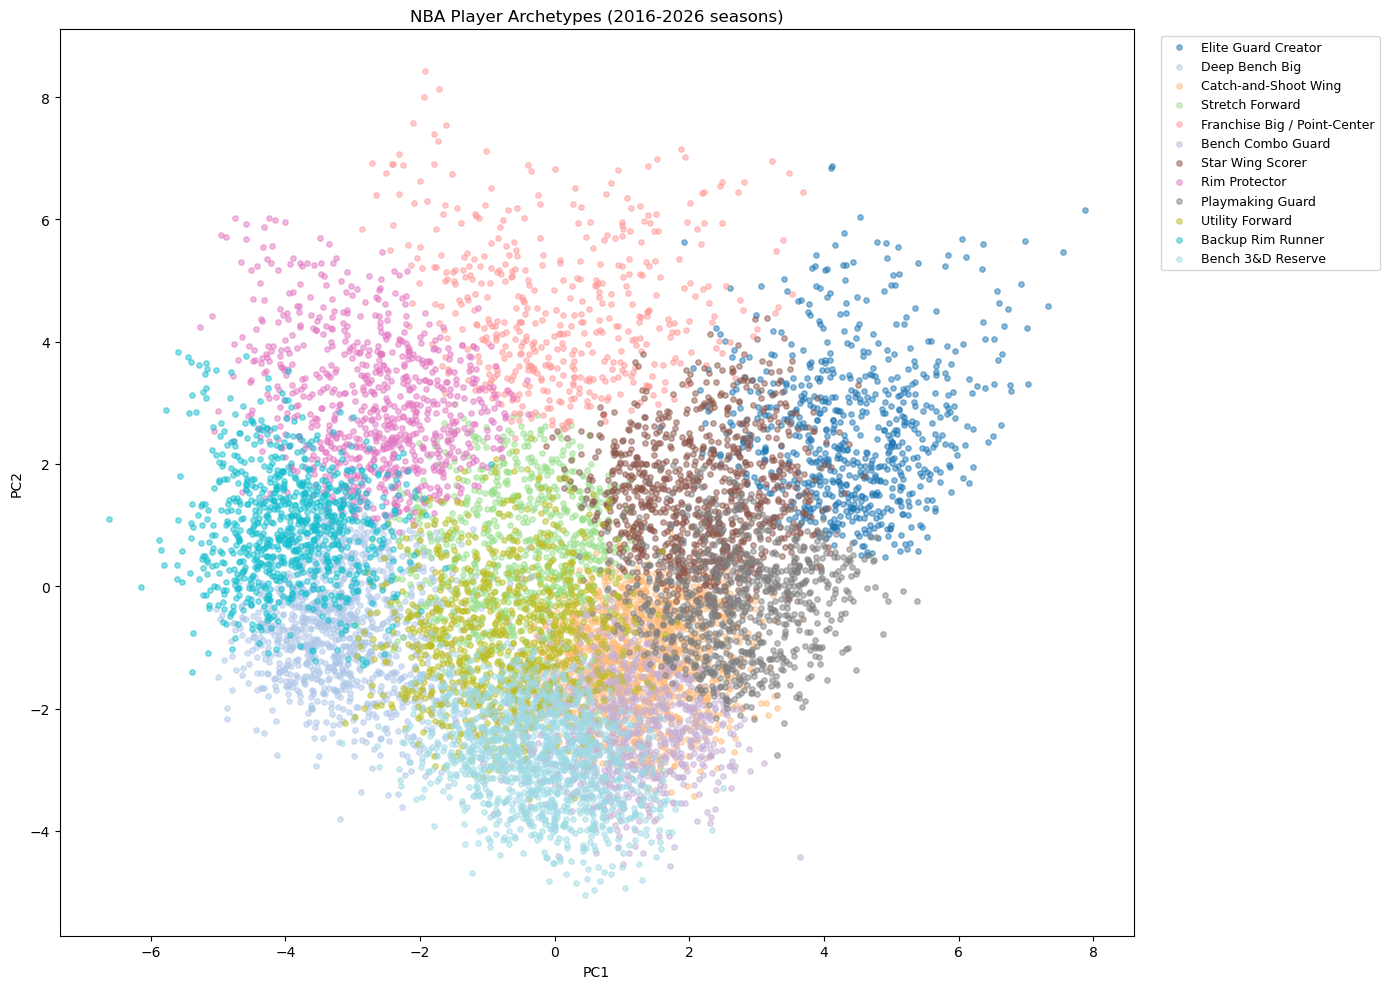

In [38]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# --- Mapping cluster numbers to the archetype names we agreed on ---
# Keeping this as a dictionary makes the chart legend readable
# (showing "Franchise Big" instead of a meaningless number like "4").
archetype_names = {
    0: "Elite Guard Creator",
    1: "Deep Bench Big",
    2: "Catch-and-Shoot Wing",
    3: "Stretch Forward",
    4: "Franchise Big / Point-Center",
    5: "Bench Combo Guard",
    6: "Star Wing Scorer",
    7: "Rim Protector",
    8: "Playmaking Guard",
    9: "Utility Forward",
    10: "Backup Rim Runner",
    11: "Bench 3&D Reserve",
}

season_stats_filtered["archetype_name"] = season_stats_filtered["archetype_cluster_v2"].map(archetype_names)

# --- Scatter plot in PC1 vs PC2 space, colored by archetype ---
fig, ax = plt.subplots(figsize=(14, 10))

# Using a colormap with 12 visually distinct colors — tab20 has enough
# variety to keep 12 categories readable without repeating similar shades.
colors = cm.tab20(np.linspace(0, 1, 12))

for cluster_id, name in archetype_names.items():
    cluster_mask = season_stats_filtered["archetype_cluster_v2"] == cluster_id
    ax.scatter(
        pca_df_v2.loc[cluster_mask, "PC1"],
        pca_df_v2.loc[cluster_mask, "PC2"],
        c=[colors[cluster_id]],
        label=name,
        alpha=0.5,
        s=15,
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("NBA Player Archetypes (2016-2026 seasons)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
plt.tight_layout()
plt.show()

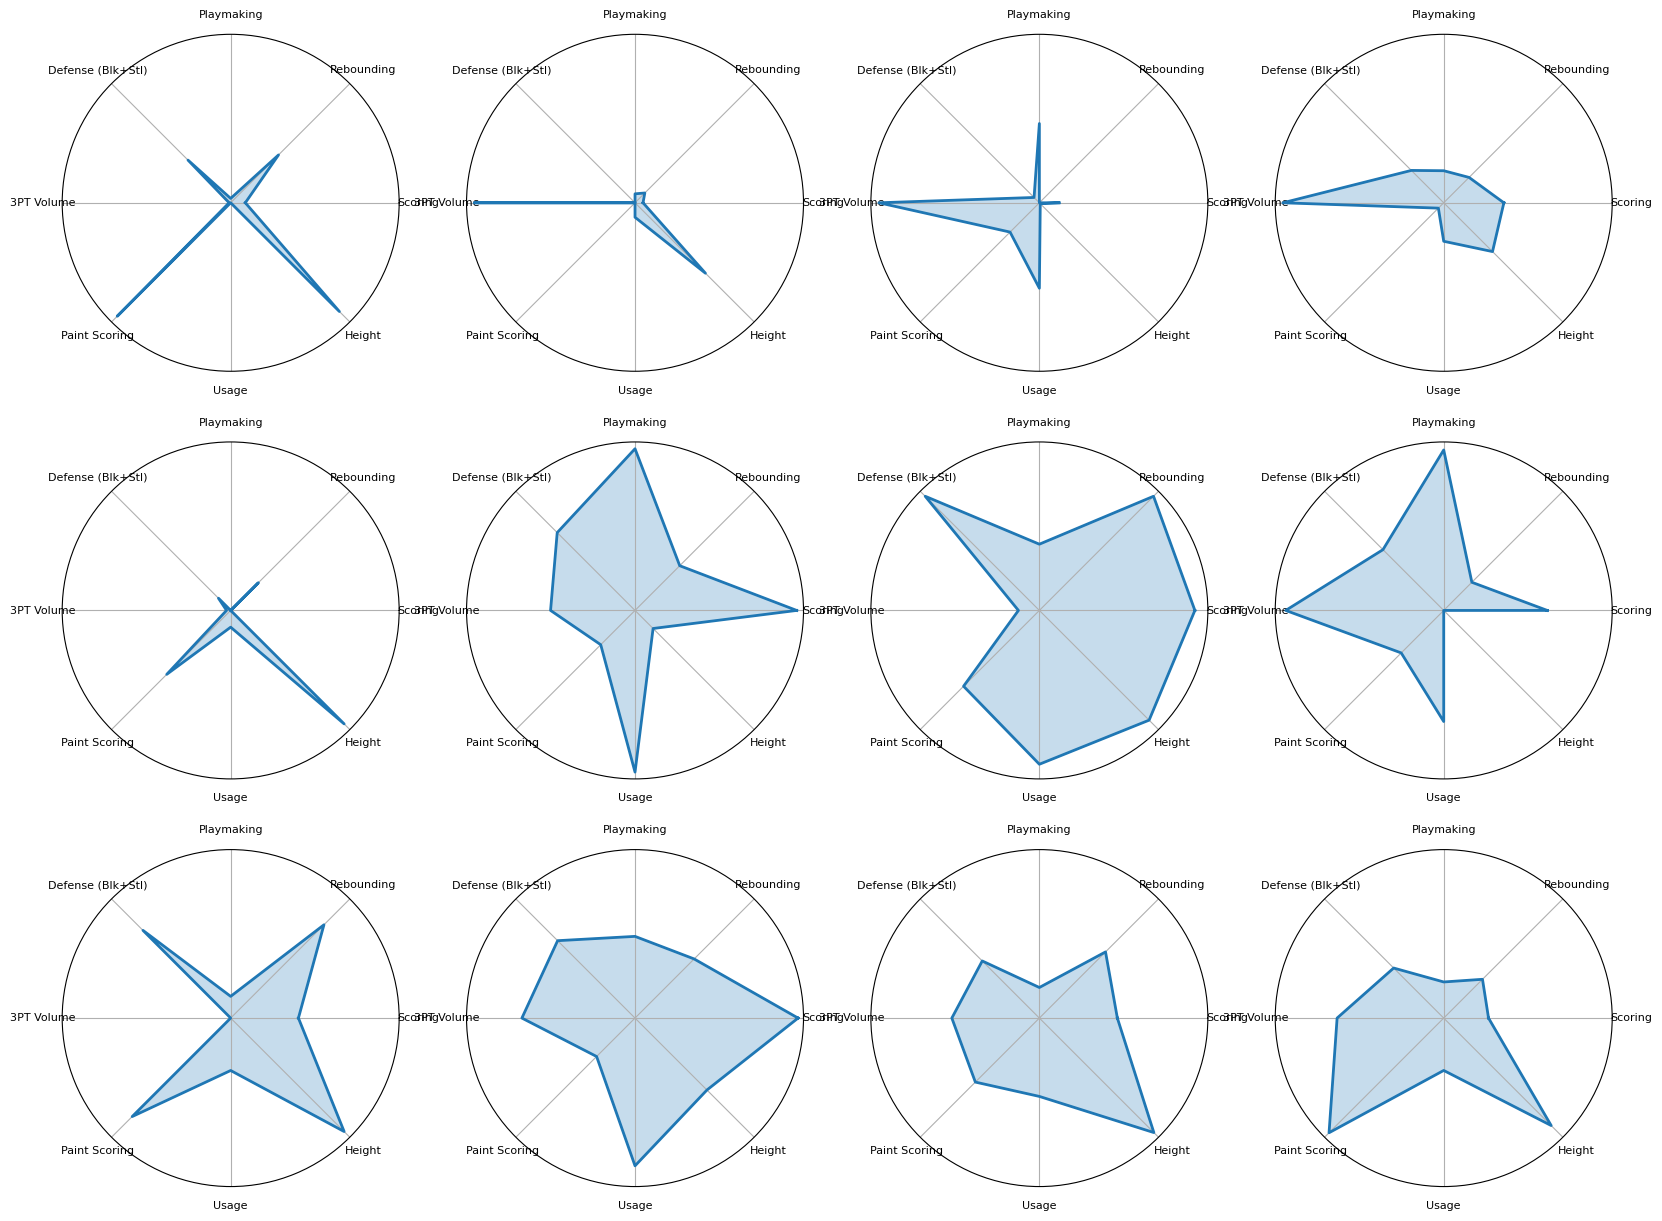

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# --- Selecting a compact, meaningful set of stats for the radar shape ---
# Using all 18 features would make the radar too cluttered to read at a
# glance — picking the ones that best capture "playing style" at a
# product level, one axis per basketball concept.
radar_features = {
    "Scoring": "points_pg",
    "Rebounding": "rebounds_pg",
    "Playmaking": "assists_pg",
    "Defense (Blk+Stl)": None,  # computed below as a combined stat
    "3PT Volume": "percentPoints3Point_wavg",
    "Paint Scoring": "percentPointsInPaint_wavg",
    "Usage": "usagePercentage_wavg",
    "Height": "heightInches",
}

# Combining blocks + steals into a single "defensive activity" stat,
# since showing them as two separate thin slices adds clutter without
# much extra insight for a product-level chart.
season_stats_filtered["defense_activity"] = (
    season_stats_filtered["blocks_pg"] + season_stats_filtered["steals_pg"]
)
radar_features["Defense (Blk+Stl)"] = "defense_activity"

# --- Computing cluster averages for these specific stats ---
radar_cols = list(radar_features.values())
cluster_means = season_stats_filtered.groupby("archetype_name")[radar_cols].mean()

# --- Normalizing each stat to a 0-1 scale across clusters ---
# Min-max scaling here (not StandardScaler like before) because for a
# radar chart, 0-1 is easier to read visually — "this archetype scores
# near the top of all archetypes on paint scoring" is more intuitive
# than a z-score value.
normalized = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())
normalized.columns = list(radar_features.keys())

# --- Building a grid of 12 small radar charts, one per archetype ---
# Small multiples avoid the overlap problem entirely — instead of 12
# shapes fighting for the same space, each archetype gets its own
# clean panel, and they're all on the same scale so they're directly
# comparable side by side.
n_axes = len(radar_features)
angles = np.linspace(0, 2 * np.pi, n_axes, endpoint=False).tolist()
angles += angles[:1]  # closing the loop back to the first axis

fig, axes = plt.subplots(3, 4, figsize=(20, 15), subplot_kw=dict(polar=True))
axes = axes.flatten()

for idx, (archetype, row) in enumerate(normalized.iterrows()):
    ax = axes[idx]
    values = row.tolist()
    values += values[:1]  # closing the loop, matching angles

    ax.plot(angles, values, linewidth=2, color="#1f77b4")
    ax.fill(angles, values, alpha=0.25, color="#1f77b4")
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(list(radar_features.keys()), fontsize=8)
    ax.set_yticks([])  # hiding radial